<a href="https://colab.research.google.com/github/RaghuVemuluri/GitLab/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data = pd.read_csv('/content/customer_support_tickets.csv')
data.head()


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [43]:
data = pd.read_csv("customer_support_tickets.csv")

print(data.head())
print(data.info())
print(data.describe())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

# New Section

In [ ]:
data.info()
data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [27]:
data = data[data['Ticket Status'] == 'Closed']


In [28]:
data['First Response Time'] = pd.to_datetime(data['First Response Time'])
data['Time to Resolution'] = pd.to_datetime(data['Time to Resolution'])
data['Date of Purchase'] = pd.to_datetime(data['Date of Purchase'])


In [29]:
data['Response_Delay'] = (data['Time to Resolution'] - data['First Response Time']).dt.total_seconds()/3600
data['Purchase_Year'] = data['Date of Purchase'].dt.year
data['Purchase_Month'] = data['Date of Purchase'].dt.month


In [30]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=500)
text_features = cv.fit_transform(data['Ticket Description']).toarray()

text_df = pd.DataFrame(text_features, columns=cv.get_feature_names_out())


In [31]:
final_data = pd.concat([data.reset_index(drop=True), text_df], axis=1)

final_data = final_data[[
    'Customer Age',
    'Ticket Priority',
    'Ticket Channel',
    'Response_Delay',
    'Purchase_Year',
    'Purchase_Month',
    'Customer Satisfaction Rating'
] + list(text_df.columns)]


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

final_data['Ticket Priority'] = le.fit_transform(final_data['Ticket Priority'])
final_data['Ticket Channel'] = le.fit_transform(final_data['Ticket Channel'])


In [33]:
final_data.dropna(inplace=True)


In [34]:
X = final_data.drop('Customer Satisfaction Rating', axis=1)
y = final_data['Customer Satisfaction Rating']


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)


RandomForestClassifier()

In [41]:
y_pred = model.predict(X_test)


In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.2148014440433213
              precision    recall  f1-score   support

         1.0       0.24      0.25      0.24       109
         2.0       0.24      0.21      0.22       117
         3.0       0.21      0.26      0.23       112
         4.0       0.20      0.19      0.20       108
         5.0       0.18      0.17      0.17       108

    accuracy                           0.21       554
   macro avg       0.21      0.21      0.21       554
weighted avg       0.22      0.21      0.21       554

[[27 18 30 16 18]
 [22 24 26 30 15]
 [19 19 29 22 23]
 [24 15 23 21 25]
 [20 22 30 18 18]]


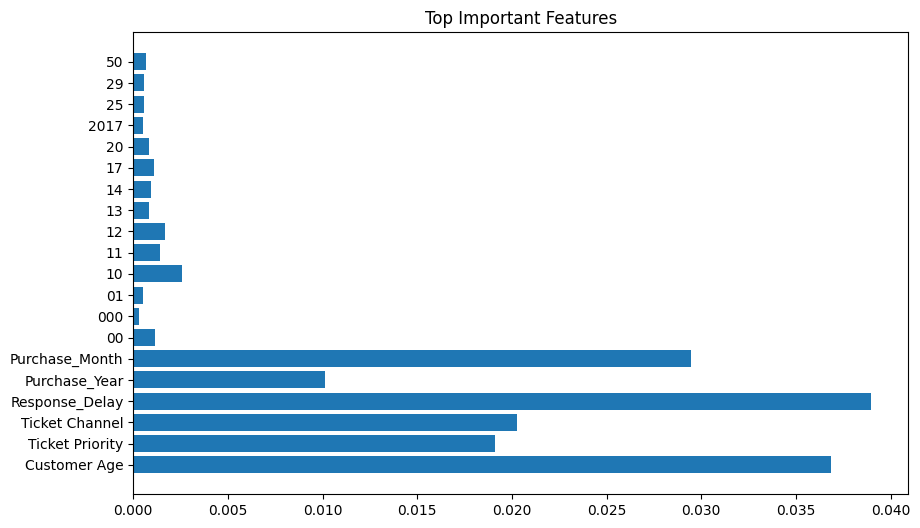

In [39]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feat_names = X.columns

plt.figure(figsize=(10,6))
plt.barh(feat_names[:20], importances[:20])
plt.title("Top Important Features")
plt.show()


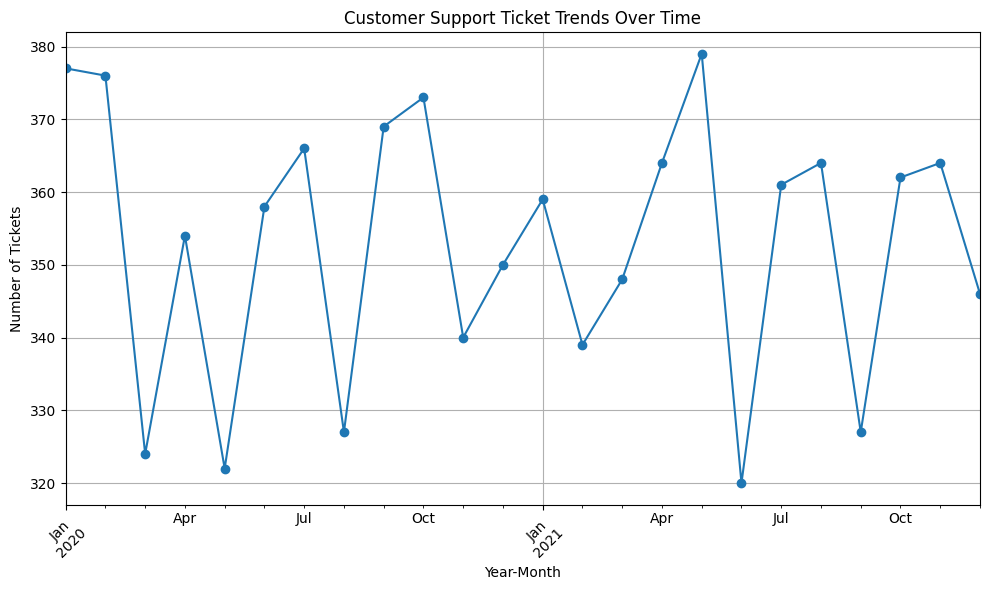

In [46]:
# Analyze customer support ticket trends

data['Date of Purchase'] = pd.to_datetime(data['Date of Purchase'])
data['YearMonth'] = data['Date of Purchase'].dt.to_period('M')

ticket_trends = data.groupby('YearMonth').size()

plt.figure(figsize=(10,6))
ticket_trends.plot(kind='line', marker='o')

plt.title('Customer Support Ticket Trends Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Number of Tickets')
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

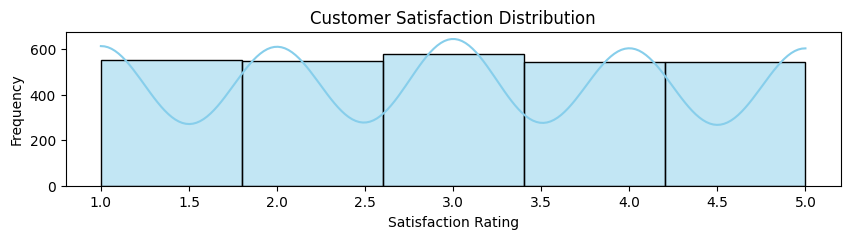

In [51]:
# Customer Satisfaction Distribution

plt.figure(figsize=(10,2))

sns.histplot(data['Customer Satisfaction Rating'], bins=5, kde=True, color='skyblue')

plt.title('Customer Satisfaction Distribution')
plt.xlabel('Satisfaction Rating')
plt.ylabel('Frequency')

plt.show()

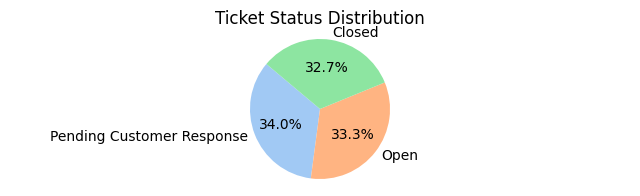

In [50]:
# Ticket Status Distribution

ticket_status_distribution = data['Ticket Status'].value_counts()

plt.figure(figsize=(8, 2))

plt.pie(ticket_status_distribution,
        labels=ticket_status_distribution.index,
        autopct='%1.1f%%',
        colors=sns.color_palette('pastel'),
        startangle=140)

plt.title('Ticket Status Distribution')

plt.axis('equal')

plt.show()

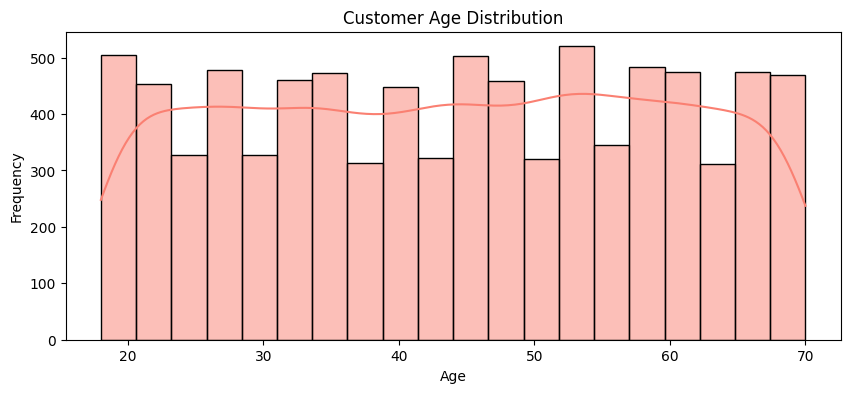

In [53]:
# Customer Age Distribution

plt.figure(figsize=(10, 4))

sns.histplot(data['Customer Age'], bins=20, kde=True, color='salmon')

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

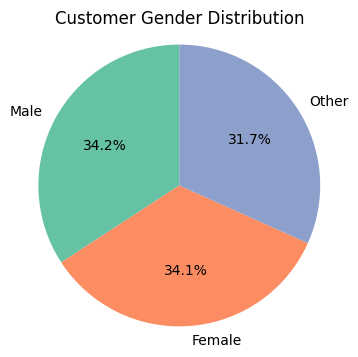

In [55]:
# Customer Gender Distribution

customer_gender_distribution = data['Customer Gender'].value_counts()

plt.figure(figsize=(4, 4))

plt.pie(customer_gender_distribution,
        labels=customer_gender_distribution.index,
        autopct='%1.1f%%',
        colors=sns.color_palette('Set2'),
        startangle=90)

plt.title('Customer Gender Distribution')

plt.axis('equal')

plt.show()

/tmp/ipykernel_1144/999912533.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ticket_channel_distribution.index,


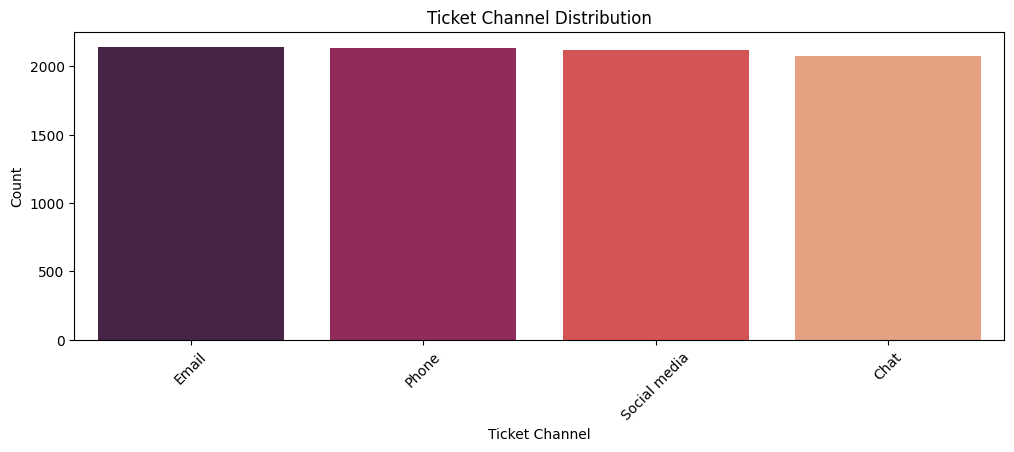

In [63]:
# Ticket Channel Distribution

plt.figure(figsize=(12, 4))

ticket_channel_distribution = data['Ticket Channel'].value_counts()

sns.barplot(x=ticket_channel_distribution.index,
            y=ticket_channel_distribution,
            palette='rocket')

plt.title('Ticket Channel Distribution')
plt.xlabel('Ticket Channel')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

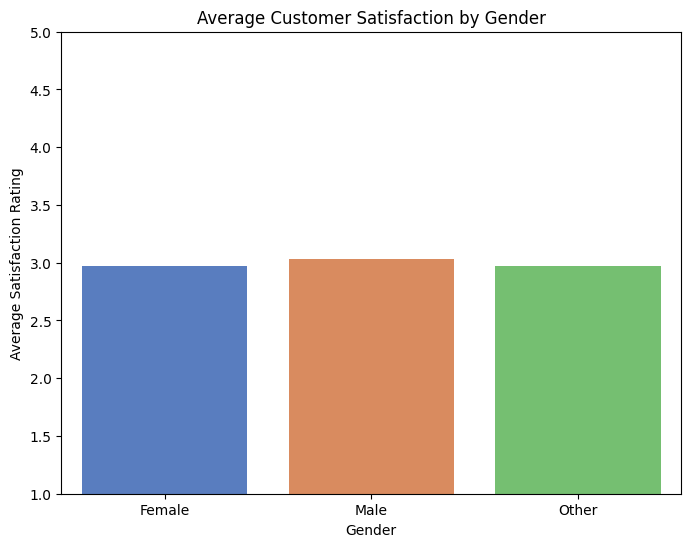

In [65]:
average_satisfaction = data.groupby('Customer Gender')['Customer Satisfaction Rating'].mean().reset_index()

plt.figure(figsize=(8,6))

sns.barplot(
    x='Customer Gender',
    y='Customer Satisfaction Rating',
    data=average_satisfaction,
    hue='Customer Gender',
    palette='muted',
    legend=False
)

plt.title('Average Customer Satisfaction by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Satisfaction Rating')

plt.ylim(1,5)

plt.show()

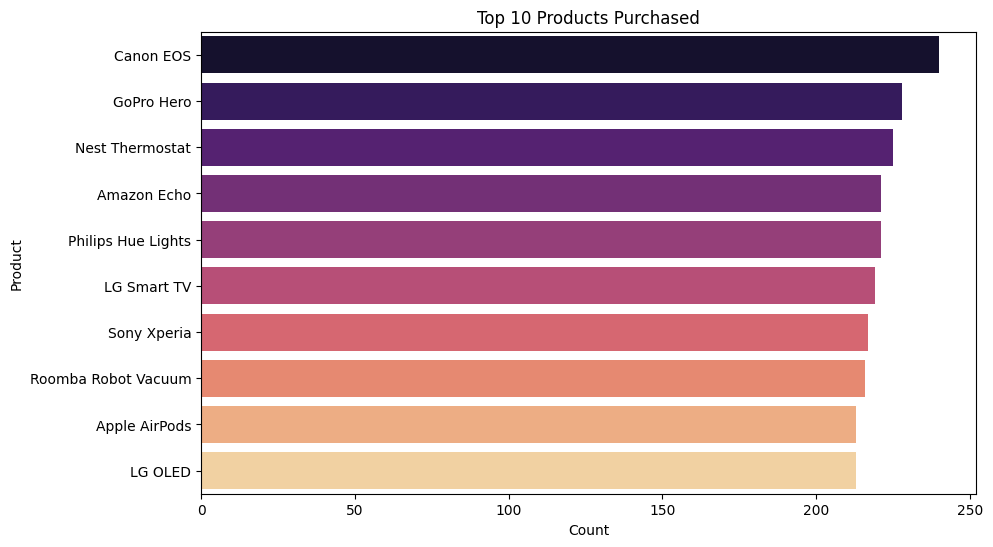

In [66]:
# Product Purchased Distribution

plt.figure(figsize=(10,6))

product_purchased_distribution = data['Product Purchased'].value_counts().head(10)

sns.barplot(
    y=product_purchased_distribution.index,
    x=product_purchased_distribution,
    hue=product_purchased_distribution.index,
    palette='magma',
    legend=False
)

plt.title('Top 10 Products Purchased')
plt.xlabel('Count')
plt.ylabel('Product')

plt.show()

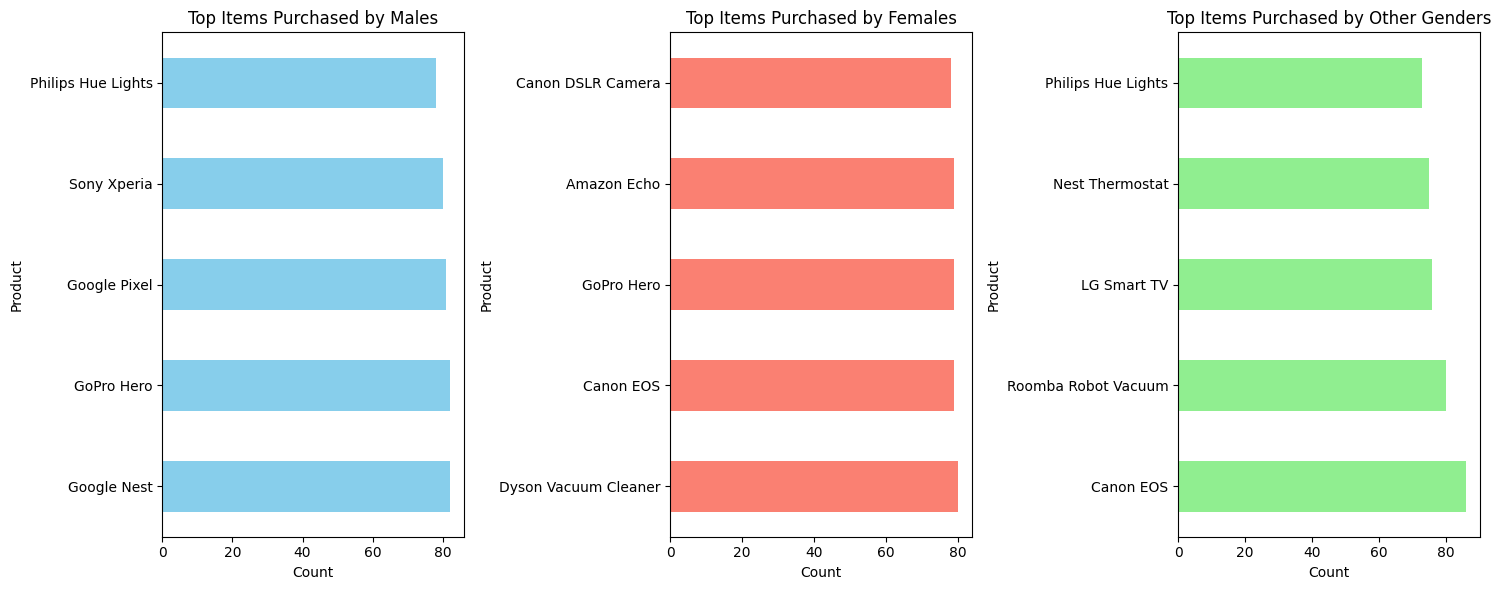

In [67]:
# Chart: Top Items Purchased by Gender

plt.figure(figsize=(15,6))

# Top Items Purchased by Males
plt.subplot(1,3,1)

top_items_male = data[data['Customer Gender']=='Male']['Product Purchased'].value_counts().head(5)

top_items_male.plot(kind='barh', color='skyblue')

plt.title('Top Items Purchased by Males')
plt.xlabel('Count')
plt.ylabel('Product')


# Top Items Purchased by Females
plt.subplot(1,3,2)

top_items_female = data[data['Customer Gender']=='Female']['Product Purchased'].value_counts().head(5)

top_items_female.plot(kind='barh', color='salmon')

plt.title('Top Items Purchased by Females')
plt.xlabel('Count')
plt.ylabel('Product')


# Top Items Purchased by Other Gender
plt.subplot(1,3,3)

top_items_other = data[data['Customer Gender']=='Other']['Product Purchased'].value_counts().head(5)

top_items_other.plot(kind='barh', color='lightgreen')

plt.title('Top Items Purchased by Other Genders')
plt.xlabel('Count')
plt.ylabel('Product')


plt.tight_layout()

plt.show()

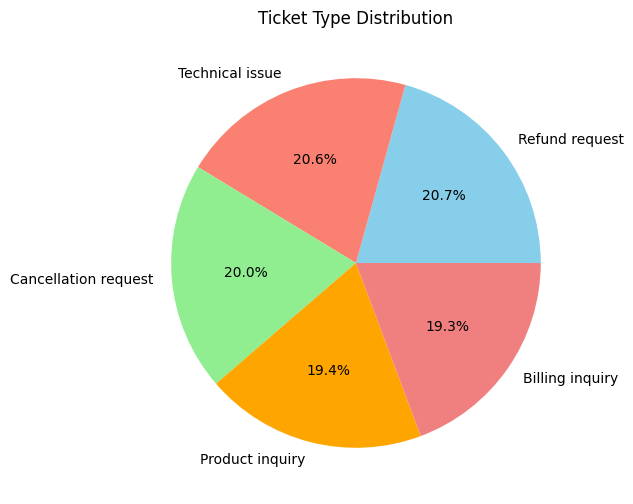

In [68]:
# Ticket Type Distribution

ticket_type_distribution = data['Ticket Type'].value_counts()

plt.figure(figsize=(8,6))

ticket_type_distribution.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','salmon','lightgreen','orange','lightcoral']
)

plt.title('Ticket Type Distribution')

plt.ylabel('')

plt.show()

/tmp/ipykernel_1144/1925115523.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tickets_by_age_group = data.groupby('Age Group').size()


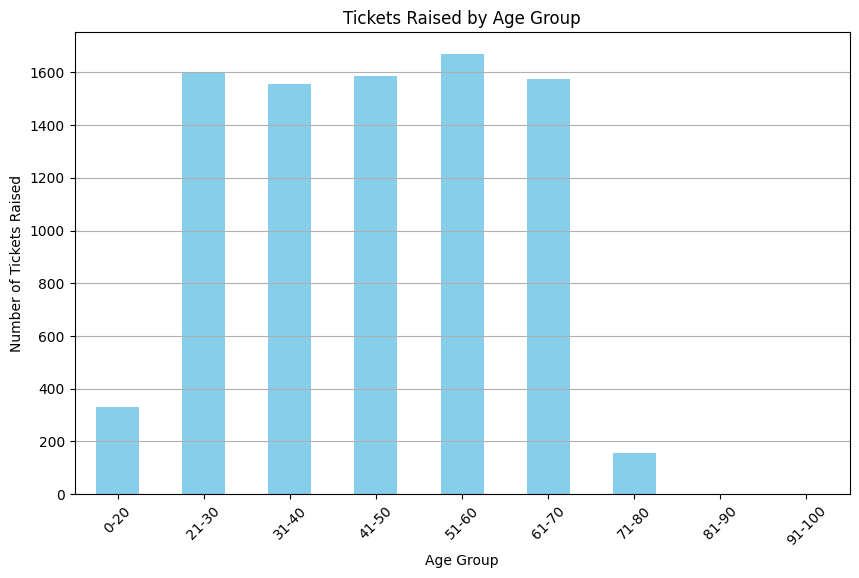

In [69]:
# Define age groups

bins = [0,20,30,40,50,60,70,80,90,100]

labels = ['0-20','21-30','31-40','41-50','51-60','61-70','71-80','81-90','91-100']


# Categorize customers into age groups

data['Age Group'] = pd.cut(data['Customer Age'], bins=bins, labels=labels, right=False)


# Calculate number of tickets raised by each age group

tickets_by_age_group = data.groupby('Age Group').size()


# Plot graph

plt.figure(figsize=(10,6))

tickets_by_age_group.plot(kind='bar', color='skyblue')

plt.title('Tickets Raised by Age Group')

plt.xlabel('Age Group')

plt.ylabel('Number of Tickets Raised')

plt.xticks(rotation=45)

plt.grid(axis='y')

plt.show()

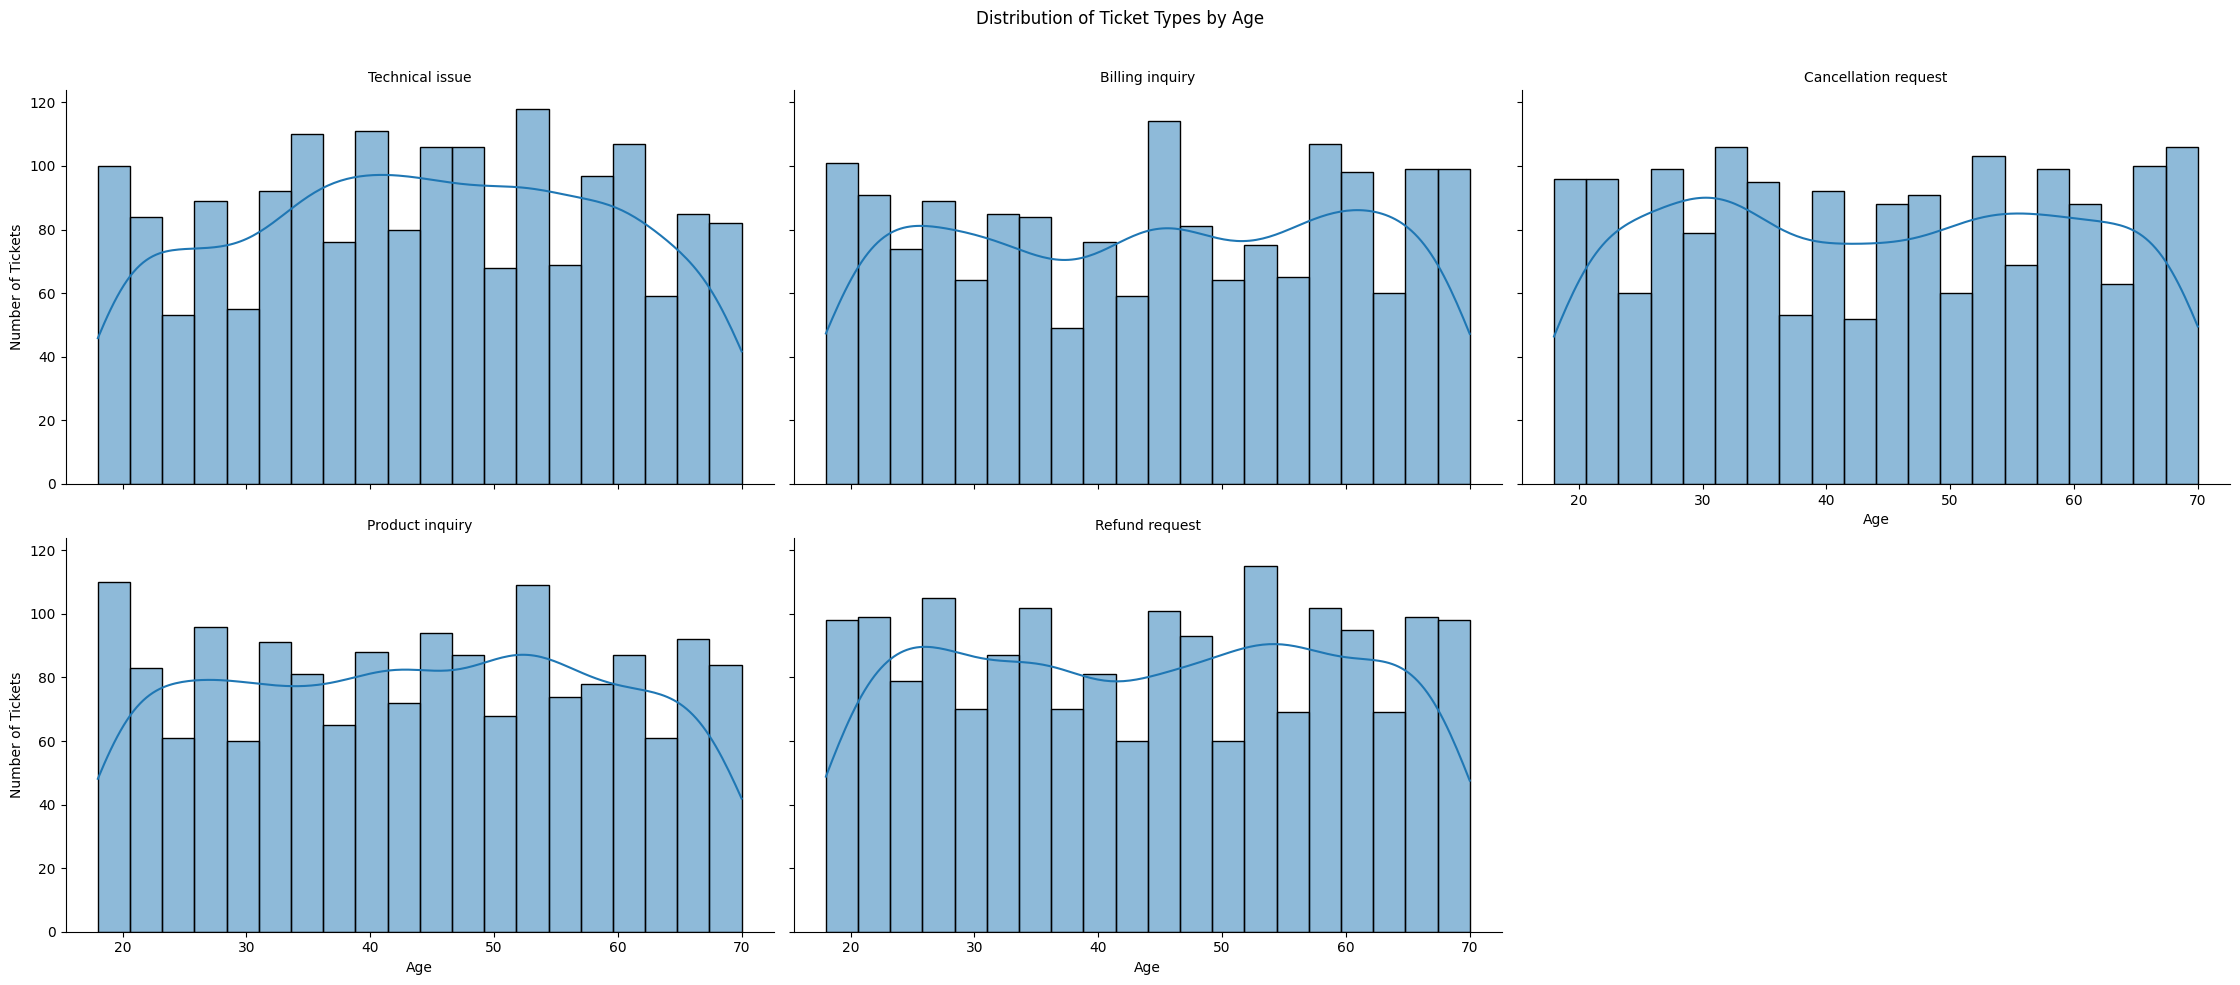

In [70]:
# Replace inf values with NaN
data.replace([np.inf, -np.inf], np.nan, inplace=True)


# Create facet grid for each ticket type
g = sns.FacetGrid(data, col='Ticket Type', col_wrap=3, height=5, aspect=1.5)


# Plot age distribution for each ticket type
g.map(sns.histplot, 'Customer Age', bins=20, kde=True)


# Set titles and labels
g.set_titles('{col_name}')
g.set_axis_labels('Age', 'Number of Tickets')


# Adjust layout
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribution of Ticket Types by Age')


plt.show()